# Make Lapse Labels

Coco Yu & Claire Punturieri  
September 15, 2024

## Code Status

## Notes

-   We dropped participants who didn’t complete follow-up 1.

-   John and Kendra have decided to drop subid 104’s data for the following reasons:

    -   They had lapses every day on study except one day.  
    -   Only had 75 surveys where a lapse was not reported.  
    -   Viewing their lapse times it appears they were drinking constantly (morning and night).  
    -   They consistently report being uncertain that their goal is to be abstinent (uncertain on 125 of 137 lapses. They also report they are uncertain in this goal at followup 1 and 2.  
    -   They are ultimately discontinued since they were struggling to gain sobriety.  
    -   Unfortunately this drops 109 valid lapses.

-   John and Kendra have decided to drop subid 269’s data for the following reasons:

    -   They completed 10-15 surveys on many days on study (avg number of surveys per day is 6.76).  
    -   Their responses indicate careless responding - they were filling 2-4 surveys out within an hour of each other and the responses to the questions were completely different.  
    -   They have questionable no lapse labels - they reported no lapses while on study but according to notes left two messages for study staff where they admitted to drinking over the weekend.

-   John and Kendra have decided to drop subid 204’s data for the following reasons:

    -   Subid 204 had extremely poor compliance. 33 out of 89 study days had an EMA completed. They only did a total of 5 surveys between followup 2 and 3.  
    -   We don’t trust their lapse labels - They report several lapses during their interviews but times appear questionable (same time every night). They only report 1 lapse with EMA.
    -   From notes - “Participant did not do many surveys during their second month of participation. At their Follow-up 2 visit they reported several lapses that were not documented in their EMAs - estimated lapse days/times in subid’s raw data log.”  
    -   JC note: “There are issues with 204. They are missing lapses reported by interview. But they  
        also stopped doing any ema by 5/17 even though their study end date was 6/13. Probably need to drop them for lapse analyses for anything after 5/17. Probably also need to add in their reported lapses at follow-up 2. OR we drop them at the end of follow-up 1 or wherever their ema gets sketchy”

-   hand-edit lapse_start for subid 213

## Setup

Chunk Defaults

In [ ]:
knitr::opts_chunk$set(attr.output='style="max-height: 500px;"')


Conflicts

In [ ]:
options(conflicts.policy = "depends.ok")


In [ ]:
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

here() starts at /Users/yujiachen/Desktop/github/study_messages

Source Functions

In [ ]:
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true")


ℹ SHA-1 hash of file is "a58e57da996d1b70bb9a5b58241325d6fd78890f"

ℹ SHA-1 hash of file is "c045eee2655a18dc85e715b78182f176327358a7"

Absolute Paths

In [ ]:
path_shared <- format_path(str_c("studydata/risk/data_processed/shared"))
path_messages <- format_path(str_c("studydata/risk/data_processed/messages"))


## Read in Data

need further cleaning on lapses: for now, NA if NA in start_time

In [ ]:
visit_dates <- read_csv(here(path_messages, "study_dates.csv"),
                             col_types = cols()) |> 
  mutate(start_study = as_datetime(start_study, tz = "America/Chicago"),
         end_study = as_datetime(end_study, tz = "America/Chicago")) |> 
  glimpse()


Rows: 139
Columns: 3
$ subid       <dbl> 2, 3, 5, 6, 7, 9, 10, 11, 15, 16, 18, 19, 20, 21, 23, 25, …
$ start_study <dttm> 2017-03-24, 2017-03-22, 2017-06-20, 2017-06-15, 2017-06-1…
$ end_study   <dttm> 2017-06-16, 2017-06-20, 2017-09-18, 2017-09-13, 2017-09-1…

Rows: 1,083
Columns: 15
$ subid            <dbl> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 1…
$ source           <chr> "ema", "ema", "ema", "ema", "ema", "ema", "ema", "ema…
$ response_id      <chr> "R_3RlVHp8Q2wK8V0K", "R_zYDlbhrTAgwipsR", "R_2S7H3Dz4…
$ lapse_start_time <chr> "17:00", "17:00", "17:00", "19:00", "18:00", "17:00",…
$ lapse_start_date <chr> "9/4/17", "9/29/17", "9/22/17", "9/22/17", "9/13/17",…
$ lapse_start      <dttm> 2017-09-04 17:00:00, 2017-09-29 17:00:00, 2017-09-22…
$ lapse_end_time   <chr> "23:00", "19:00", "18:00", "21:00", "21:00", "21:00",…
$ lapse_end_date   <chr> "9/4/17", "9/29/17", "9/22/17", "9/22/17", "9/13/17",…
$ lapse_end        <dttm> 2017-09-05 04:00:00, 2017-09-30 00:00:00, 2017-09-22…
$ lapse_cnt        <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,…
$ exclude          <chr> "FALSE", "FALSE", "FALSE", "FALSE", "FALSE", "FALSE",…
$ ema_end          <dttm> 2017-10-12 03:41:29, 2017-10-12 03:41:29, 2017-10-12…
$ ema_1_6       

In [ ]:
labels <- visit_dates |> 
  rowwise() |>
  mutate(day_start = list(seq.POSIXt(start_study + days(1), end_study - days(1), by = "day"))) |> 
  unnest(day_start) |>
  mutate(day_start = update(day_start, hour = 4, minute = 0)) |> 
  select(subid, day_start) |> 
  glimpse()


Rows: 11,702
Columns: 2
$ subid     <dbl> 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ day_start <dttm> 2017-03-25 04:00:00, 2017-03-26 04:00:00, 2017-03-27 04:00:…

clean up lapse start

In [ ]:
lapses <- lapses |> 
  mutate(
    lapse_end_date = if_else(is.na(lapse_end_date),
                             format(mdy(lapse_start_date) + days(1), "%m/%d/%Y"),
                             lapse_end_date),
    lapse_start_time = if_else(is.na(lapse_start_time), "20:00", lapse_start_time),
    lapse_end_time = if_else(is.na(lapse_end_time), "2:00", lapse_end_time),
    lapse_start = mdy_hm(paste(lapse_start_date, lapse_start_time)),
    lapse_start = force_tz(lapse_start, tzone = ema_1_6),
    lapse_start = as_datetime(lapse_start, tz = "America/Chicago"),
    lapse_end = mdy_hm(paste(lapse_end_date, lapse_end_time)),
    lapse_end = force_tz(lapse_end, tzone = ema_1_6),
    lapse_end = as_datetime(lapse_end, tz = "America/Chicago")
    ) |> 
  glimpse()


Rows: 1,083
Columns: 15
$ subid            <dbl> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 1…
$ source           <chr> "ema", "ema", "ema", "ema", "ema", "ema", "ema", "ema…
$ response_id      <chr> "R_3RlVHp8Q2wK8V0K", "R_zYDlbhrTAgwipsR", "R_2S7H3Dz4…
$ lapse_start_time <chr> "17:00", "17:00", "17:00", "19:00", "18:00", "17:00",…
$ lapse_start_date <chr> "9/4/17", "9/29/17", "9/22/17", "9/22/17", "9/13/17",…
$ lapse_start      <dttm> 2017-09-04 17:00:00, 2017-09-29 17:00:00, 2017-09-22…
$ lapse_end_time   <chr> "23:00", "19:00", "18:00", "21:00", "21:00", "21:00",…
$ lapse_end_date   <chr> "9/4/17", "9/29/17", "9/22/17", "9/22/17", "9/13/17",…
$ lapse_end        <dttm> 2017-09-04 23:00:00, 2017-09-29 19:00:00, 2017-09-22…
$ lapse_cnt        <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,…
$ exclude          <chr> "FALSE", "FALSE", "FALSE", "FALSE", "FALSE", "FALSE",…
$ ema_end          <dttm> 2017-10-12 03:41:29, 2017-10-12 03:41:29, 2017-10-12…
$ ema_1_6       

[1] FALSE

[1] FALSE

join lapses to labels

In [ ]:
labels <- labels |> 
  mutate(day_end = day_start + days(1) - seconds(1),
         lapse = NA)

lapses_valid <- lapses |> 
  filter(exclude == "FALSE") |> 
  filter(!is.na(lapse_start))

for (i in 1:nrow(lapses_valid)){
  labels <- labels |> 
    mutate(lapse = if_else(subid == lapses_valid$subid[i] &
                             day_start <= lapses_valid$lapse_start[i] &
                             day_end >= lapses_valid$lapse_start[i],
                           "lapse", lapse))
}

lapses_exclude <- lapses |> 
  filter(exclude == "TRUE") |> 
  filter(!is.na(lapse_start))

for (i in 1:nrow(lapses_exclude)){
  labels <- labels |> 
    mutate(lapse = if_else(subid == lapses_exclude$subid[i] &
                             day_start <= lapses_exclude$lapse_start[i] &
                             day_end >= lapses_exclude$lapse_start[i],
                           "exclude", lapse),
           lapse = if_else(subid == lapses_exclude$subid[i] &
                             day_start <= lapses_exclude$lapse_end[i] &
                             day_end >= lapses_exclude$lapse_end[i],
                           "exclude", lapse))
}

labels <- labels |> 
  mutate(lapse = if_else(is.na(lapse), "no lapse", lapse)) |> 
  filter(lapse != "exclude")


## EDA

In [ ]:
(length(unique(labels$subid)))


[1] 139

In [ ]:
labels |> 
  group_by(subid, lapse) |> 
  summarize(n = n()) |> 
  print_kbl()


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

number of days by participant

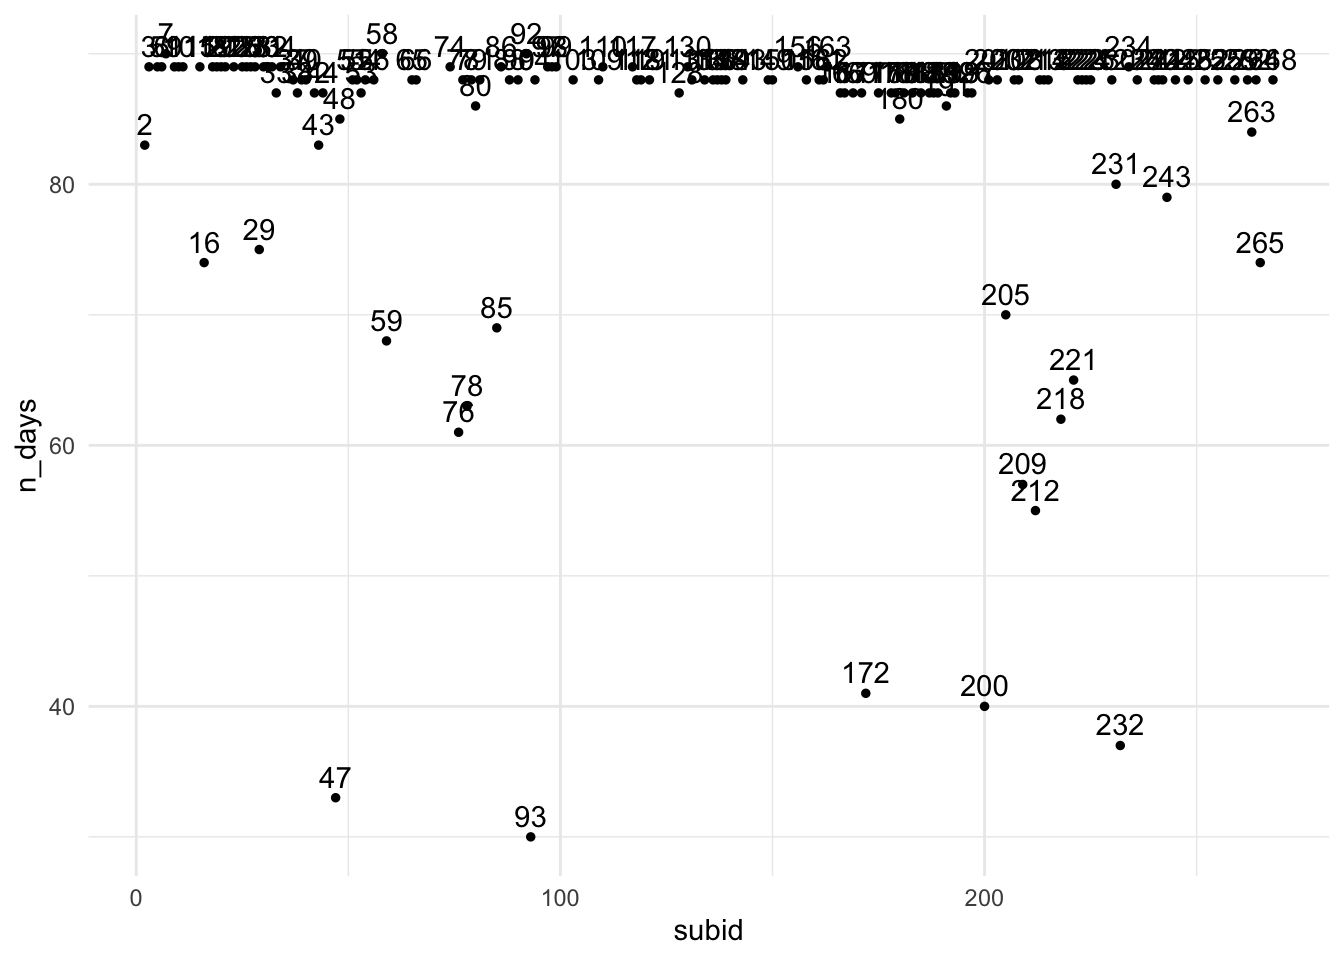

In [ ]:
labels |> 
  group_by(subid) |>
  summarize(n_days = n()) |>
  ggplot(aes(x = subid, y = n_days)) +
  geom_point(size = 1) +
  geom_text(aes(label = subid), vjust = -0.5, hjust = 0.5) +
  theme_minimal()


number of lapses by participant

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

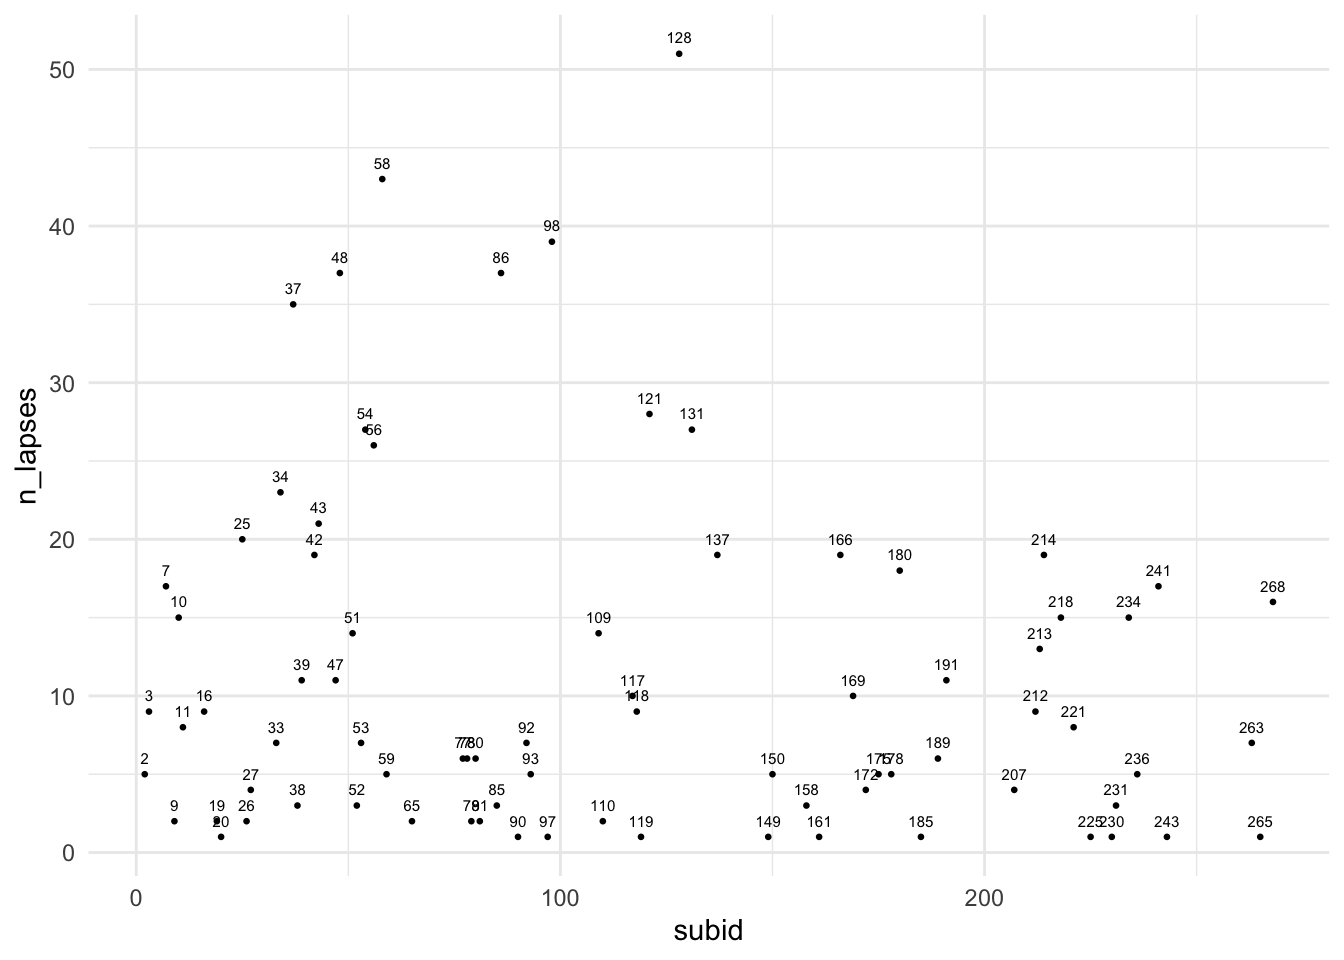

In [ ]:
labels |> 
  group_by(subid, lapse) |> 
  summarize(n_lapses = n()) |>
  filter(lapse == "lapse") |> 
  ggplot(aes(x = subid, y = n_lapses)) +
  geom_point(size = 0.5) +
  geom_text(aes(label = subid), vjust = -1, hjust = 0.5, size = 2) +
  theme_minimal()


percentage of lapses by participant

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.
Joining with `by = join_by(subid)`

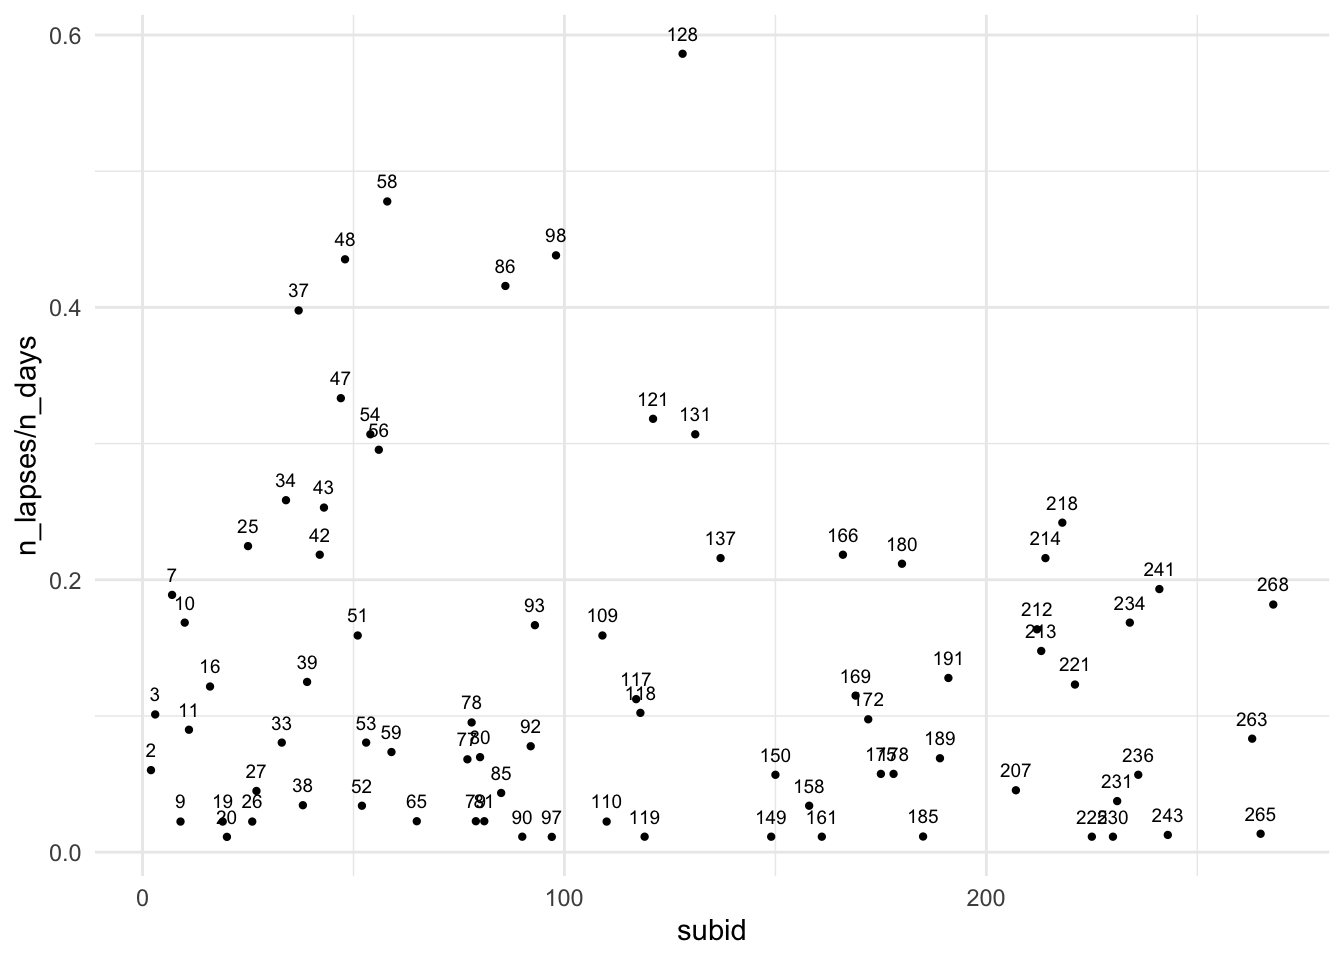

In [ ]:
labels |> 
  group_by(subid, lapse) |> 
  summarize(n_lapses = n()) |>
  full_join(labels |> group_by(subid) |> summarize(n_days = n())) |> 
  filter(lapse == "lapse") |> 
  ggplot(aes(x = subid, y = n_lapses/n_days)) +
  geom_point(size = 0.8) +
  geom_text(aes(label = subid), vjust = -1, hjust = 0.5, size = 2.5) +
  theme_minimal()


## Write-out csv

In [ ]:
labels |> 
  write_csv(here(path_messages, "lapses.csv")) |> 
  glimpse()


Rows: 11,683
Columns: 4
$ subid     <dbl> 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ day_start <dttm> 2017-03-25 04:00:00, 2017-03-26 04:00:00, 2017-03-27 04:00:…
$ day_end   <dttm> 2017-03-26 03:59:59, 2017-03-27 03:59:59, 2017-03-28 03:59:…
$ lapse     <chr> "no lapse", "no lapse", "no lapse", "no lapse", "no lapse", …